100%|██████████| 26.4M/26.4M [00:03<00:00, 7.72MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 137kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.8MB/s]



===== Experiment 1 =====
Epoch 1
Loss: 0.5172
Accuracy: 81.34%
---------------------
Epoch 2
Loss: 0.3855
Accuracy: 85.89%
---------------------
Epoch 3
Loss: 0.3443
Accuracy: 87.29%
---------------------
Epoch 4
Loss: 0.3207
Accuracy: 88.03%
---------------------
Epoch 5
Loss: 0.2998
Accuracy: 88.78%
---------------------
Epoch 6
Loss: 0.2850
Accuracy: 89.42%
---------------------
Epoch 7
Loss: 0.2701
Accuracy: 89.96%
---------------------
Epoch 8
Loss: 0.2591
Accuracy: 90.45%
---------------------
Epoch 9
Loss: 0.2474
Accuracy: 90.70%
---------------------
Epoch 10
Loss: 0.2384
Accuracy: 91.12%
---------------------

Test Accuracy = 88.54%

===== Experiment 2 =====
Epoch 1
Loss: 0.5251
Accuracy: 81.35%
---------------------
Epoch 2
Loss: 0.3780
Accuracy: 86.23%
---------------------
Epoch 3
Loss: 0.3378
Accuracy: 87.52%
---------------------
Epoch 4
Loss: 0.3116
Accuracy: 88.48%
---------------------
Epoch 5
Loss: 0.2911
Accuracy: 89.26%
---------------------
Epoch 6
Loss: 0.2749
Ac

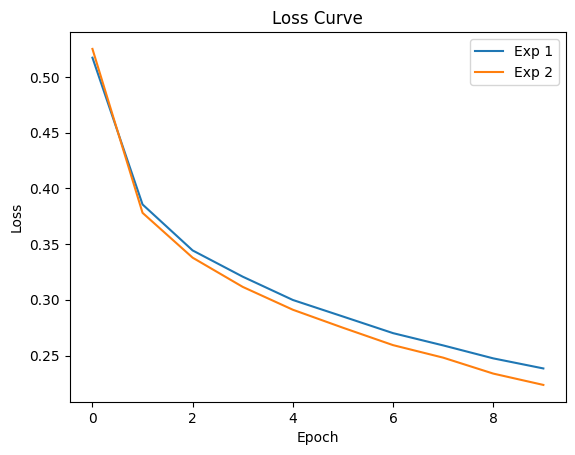

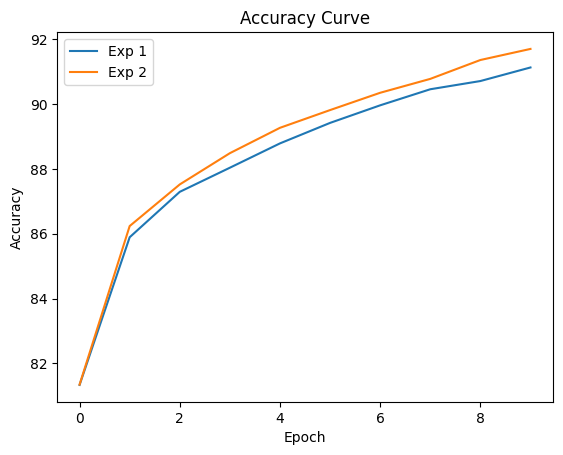

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# -----------------------------
# 1. Data Preparation
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

# -----------------------------
# 2. Model (MLP)
# -----------------------------
class MLP(nn.Module):
    def __init__(self, hidden_size=128, activation='relu'):
        super().__init__()
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(28*28, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 64)
        self.fc3 = nn.Linear(64, 10)
        
        if activation == 'relu':
            self.act = nn.ReLU()
        else:
            self.act = nn.Tanh()

    def forward(self, x):
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)
        return x

# -----------------------------
# 3. Training Function
# -----------------------------
def train_model(model, lr=0.001, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    accuracies = []
    
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        
        for images, labels in train_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
        
        acc = correct / len(train_dataset)
        train_losses.append(total_loss)
        accuracies.append(acc)
        
        print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Accuracy={acc:.4f}")
    
    return train_losses, accuracies

# -----------------------------
# 4. Evaluation
# -----------------------------
def evaluate(model):
    correct = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
    
    acc = correct / len(test_dataset)
    print(f"Test Accuracy: {acc:.4f}")
    return acc

# -----------------------------
# 5. Experiment 1 (ReLU)
# -----------------------------
model1 = MLP(hidden_size=128, activation='relu')
loss1, acc1 = train_model(model1)
test_acc1 = evaluate(model1)

# -----------------------------
# 6. Experiment 2 (Tanh)
# -----------------------------
model2 = MLP(hidden_size=128, activation='tanh')
loss2, acc2 = train_model(model2)
test_acc2 = evaluate(model2)

# -----------------------------
# 7. Visualization
# -----------------------------
plt.plot(loss1, label="ReLU Loss")
plt.plot(loss2, label="Tanh Loss")
plt.legend()
plt.title("Loss Comparison")
plt.show()

plt.plot(acc1, label="ReLU Accuracy")
plt.plot(acc2, label="Tanh Accuracy")
plt.legend()
plt.title("Accuracy Comparison")
plt.show()